# 05 — Gait位相と接地スケジュール

trotを「脚を交互に動かす」という言葉から、位相と0/1行列へ落とします。

**前提**: `04_closed_loop_timing.ipynb`

> 読み方: 「直感 → 数式 → 上流コード → 小実験 → 解釈」の順です。
> `実装事実` と書いた箇所は現行 `external/Quadruped-PyMPC` のコード、
> `学習用モデル` は理解のために単純化した再実装です。

In [1]:
from pathlib import Path
import os, sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook_pympc":
    ROOT = ROOT.parent
PYMPC_ROOT = ROOT / "external" / "Quadruped-PyMPC"
assert PYMPC_ROOT.exists(), f"Quadruped-PyMPC が見つかりません: {PYMPC_ROOT}"
if str(PYMPC_ROOT) not in sys.path:
    sys.path.insert(0, str(PYMPC_ROOT))

os.environ.setdefault("ACADOS_SOURCE_DIR", str(PYMPC_ROOT / "quadruped_pympc" / "acados"))
os.environ.setdefault("MUJOCO_GL", "egl")
print("workspace :", ROOT)
print("PyMPC root:", PYMPC_ROOT)

workspace : /home/takuya/work/mpc_dog
PyMPC root: /home/takuya/work/mpc_dog/external/Quadruped-PyMPC


## 位相モデル

各脚の位相 \(\phi_i\in[0,1)\) は

\[
\phi_i^{+}=(\phi_i+f\,\Delta t)\bmod 1
\]

と進み、duty factor \(\beta\) より小さければ接地です。

\[
c_i=\begin{cases}1 & \phi_i<\beta\\0&\text{otherwise}\end{cases}
\]

stance時間は \(\beta/f\)、swing時間は \((1-\beta)/f\) です。

shape: (4, 80) leg order: FL FR RL RR
stance/swing [s]: 0.548148148148148 0.1925925925925926


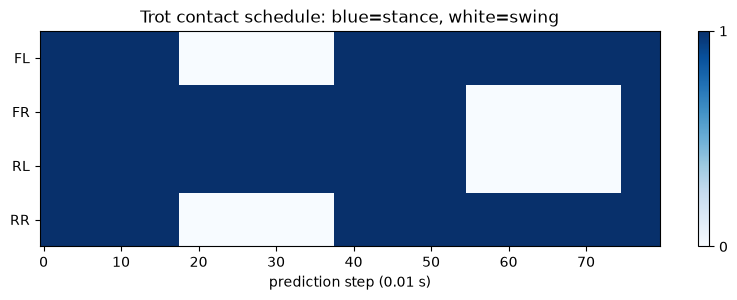

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from quadruped_pympc import config as cfg
from quadruped_pympc.helpers.periodic_gait_generator import PeriodicGaitGenerator

# config.pyから f [Hz], beta [-], gait typeを読む。
# 数式: phi_i^+ = (phi_i + f*dt) mod 1, c_i = 1[phi_i < beta]
gp = cfg.simulation_params["gait_params"]["trot"]
pgg = PeriodicGaitGenerator(
    duty_factor=gp["duty_factor"],  # beta: 1周期中の接地割合
    step_freq=gp["step_freq"],     # f: 1秒当たりの周期数
    gait_type=gp["type"],          # trot: 対角脚へ同じ位相offset
    horizon=80,
)

# 上流compute_contact_sequenceを直接実行。出力c[i,k]は4脚×80予測段。
# 内部ではrun(dt,f)を繰り返すが、計算後に現在位相を復元する。
seq = pgg.compute_contact_sequence(
    contact_sequence_dts=[0.01], contact_sequence_lenghts=[80]
)

# T_stance=beta/f, T_swing=(1-beta)/f を実装値で検算する。
print("shape:", seq.shape, "leg order: FL FR RL RR")
print("stance/swing [s]:", gp["duty_factor"]/gp["step_freq"],
      (1-gp["duty_factor"])/gp["step_freq"])
plt.figure(figsize=(10, 2.8))
plt.imshow(seq, aspect="auto", interpolation="nearest", cmap="Blues")
plt.yticks(range(4), ["FL", "FR", "RL", "RR"])
plt.xlabel("prediction step (0.01 s)")
plt.title("Trot contact schedule: blue=stance, white=swing")
plt.colorbar(ticks=[0, 1])
plt.show()

## 調整の因果

- \(f\)を上げる: 一歩が短時間になり、必要な遊脚速度・加速度が増えやすい
- \(eta\)を上げる: 接地時間が増えるが、swing時間が減る
- offsetを変える: 同時接地脚と支持多角形が変わる

`FULL_STANCE` は特別扱いで全要素1を返します。通常のoffset式だけからは説明できません。

## 章末チェック

出力を眺めるだけでなく、次を自分の言葉で答えてください。

1. この章の入力・出力の shape、単位、座標系は何か。
2. 変更可能な量と、他の章から渡される量は何か。
3. パラメータを2倍にしたとき、どのグラフがどちらへ変化するか。
4. 現行実装の事実と、学習用の近似を区別できるか。